## **Clustering with Raw EEG**
 ##### → Load & pivot
 ##### → Normalization
 ##### → Clustering (K = 2..6)
 ##### → Cluster evaluation
 ##### → Define meditation levels



### **Dataset Testing**

In [ ]:
import os

os.listdir("/content")


['.config',
 'EEG absolute and relative powers during mindfulness meditation Data from Thai Buddhist monks.zip',
 'sample_data']

In [ ]:
!unzip "/content/EEG absolute and relative powers during mindfulness meditation Data from Thai Buddhist monks.zip" -d /content/mendley_dataset


Archive:  /content/EEG absolute and relative powers during mindfulness meditation Data from Thai Buddhist monks.zip
   creating: /content/mendley_dataset/EEG absolute and relative powers during mindfulness meditation Data from Thai Buddhist monks/
  inflating: /content/mendley_dataset/__MACOSX/._EEG absolute and relative powers during mindfulness meditation Data from Thai Buddhist monks  
  inflating: /content/mendley_dataset/EEG absolute and relative powers during mindfulness meditation Data from Thai Buddhist monks/.DS_Store  
  inflating: /content/mendley_dataset/__MACOSX/EEG absolute and relative powers during mindfulness meditation Data from Thai Buddhist monks/._.DS_Store  
  inflating: /content/mendley_dataset/EEG absolute and relative powers during mindfulness meditation Data from Thai Buddhist monks/Participant characteristics - Thai monks.xlsx  
  inflating: /content/mendley_dataset/__MACOSX/EEG absolute and relative powers during mindfulness meditation Data from Thai Buddhis

In [ ]:
os.listdir("/content/mendley_dataset")


['EEG absolute and relative powers during mindfulness meditation Data from Thai Buddhist monks',
 '__MACOSX']

In [ ]:
!pip install pandas openpyxl scikit-learn --quiet


In [ ]:
import os
import pandas as pd
import numpy as np

DATA_ROOT = "/content/mendley_dataset/EEG absolute and relative powers during mindfulness meditation Data from Thai Buddhist monks"

def parse_time_window(filename):
    # Example: E1-1_t0-5min.xlsx
    return filename.split("_")[1].replace(".xlsx", "")

rows = []

for group in ["Group1", "Group2", "Group3"]:
    group_path = os.path.join(DATA_ROOT, group)
    if not os.path.isdir(group_path):
        continue

    for subject in os.listdir(group_path):
        subject_path = os.path.join(group_path, subject)
        if not os.path.isdir(subject_path):
            continue

        for file in os.listdir(subject_path):
            if not file.endswith(".xlsx"):
                continue

            file_path = os.path.join(subject_path, file)

            # Load Excel
            df = pd.read_excel(file_path)

            # Keep ONLY numeric EEG features
            numeric_df = df.select_dtypes(include=np.number)

            # Aggregate channels → mean feature vector
            feature_vector = numeric_df.mean(axis=0)

            # Metadata
            feature_vector["group"] = group
            feature_vector["subject"] = subject
            feature_vector["time_window"] = parse_time_window(file)

            rows.append(feature_vector)

print("Total samples loaded:", len(rows))


Total samples loaded: 359


In [ ]:
data = pd.DataFrame(rows)
data.head(30)


,AF3,AF4,C1,C2,C3,C4,C5,C6,CP1,CP2,...,T8,TP7,TP8,group,subject,time_window,M1,M2,Condition,TRIGGER
0,13.042788,20.191327,11.977785,10.907834,8.792451,7.381633,6.089507,4.997021,7.512991,8.214246,...,5.059918,8.423025,3.418927,Group1,E1-2,t20-25min.,NaN,NaN,NaN,NaN
1,5635.913884,2880.453078,11195.692407,8933.979936,18626.032239,7112.900967,11089.872812,2943.809614,4294.393372,11039.124108,...,359.237459,105.472857,1180.052096,Group1,E1-2,t25-30min.,NaN,NaN,NaN,NaN
2,15.411697,32.537949,15.440078,13.665010,11.321158,9.086687,7.989641,7.350332,10.136902,11.062539,...,5.222305,7.112012,3.118381,Group1,E1-2,t10-15min.,NaN,NaN,NaN,NaN
3,6.089307,13.026751,15.665531,11.436731,9.677743,7.487179,6.493295,4.850285,8.943314,9.130103,...,3.198862,3.068029,2.059510,Group1,E1-2,t5-10min.,NaN,NaN,NaN,NaN
4,14.919029,36.834168,30.621054,14.311262,15.581346,8.175516,7.257369,4.925986,9.599816,10.508251,...,7.319772,10.159564,4.442347,Group1,E1-2,t0-5min.,NaN,NaN,NaN,NaN
5,13.148737,16.479144,10.871942,10.085426,8.806069,7.622686,7.928714,6.159733,7.987988,8.601252,...,6.160533,14.666532,2.984766,Group1,E1-2,t15-20min.,NaN,NaN,NaN,NaN
6,11.965764,11.065262,9.298591,9.656135,9.340842,8.235123,5.288319,6.087983,9.004856,8.959735,...,5.148815,2.860106,5.350898,Group1,E1-11,t20-25min.,NaN,NaN,NaN,NaN
7,12.052217,11.069986,9.659314,9.326841,10.501200,8.450395,5.768761,6.535566,9.617460,8.059166,...,6.500397,3.242357,5.317765,Group1,E1-11,t10-15min.,NaN,NaN,NaN,NaN
8,11.015118,9.383407,8.035418,7.335965,8.967364,7.743058,5.002008,5.837212,8.208797,7.002293,...,4.499228,2.586035,4.821226,Group1,E1-11,t5-10min.,NaN,NaN,NaN,NaN
9,13.149114,11.955389,10.280996,10.467141,10.596192,8.990258,6.014513,6.814399,9.669997,8.975451,...,7.157828,3.494121,5.346824,Group1,E1-11,t15-20min.,NaN,NaN,NaN,NaN


### **Meditation Clustering**

In [ ]:
!pip install mne scikit-learn matplotlib seaborn scipy openneuro-py umap-learn -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.7/41.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 12.6 MB/s eta 0:00:00


In [ ]:
# All Dependencies

import os, warnings, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (silhouette_score, davies_bouldin_score, calinski_harabasz_score)

import umap

warnings.filterwarnings("ignore")

In [ ]:
DATA_ROOT = "/content/mendley_dataset/EEG absolute and relative powers during mindfulness meditation Data from Thai Buddhist monks"


In [ ]:
# Configuration

CFG = dict(
    groups       = ["Group1", "Group2", "Group3"],
    k_range      = range(2, 7),      # K = 2 … 6
    random_state = 42,

    # Outlier removal before clustering (Isolation Forest contamination rate).
    # Removes measurement artifacts / bad sessions before clustering.
    # 0.05 = remove ~5% most anomalous samples.
    outlier_contamination = 0.05,

    # After outlier removal, a cluster is degenerate only if it is a singleton
    # (size == 1). Monks data is intentionally homogeneous so small clusters
    # of 2-5 samples are real, not artefacts.
    min_cluster_size = 2,

    # Which Freq_int_name rows to USE as features
    # Absolute bands + relative (*/all) bands → richest representation
    bands_to_use = ["Delta", "Theta", "Alpha", "Beta", "Gamma",
                    "Delta/all", "Theta/all", "Alpha/all",
                    "Beta/all", "Gamma/all"],

    # Metadata columns inside each xlsx (not electrodes)
    meta_in_file = ["File", "Freq_int_name", "Freq_interval"],
)

LEVEL_NAMES = {
    0: "Level 0 — Baseline (mind-wandering)",
    1: "Level 1 — Light Relaxation",
    2: "Level 2 — Focused Attention",
    3: "Level 3 — Deep Meditation",
    4: "Level 4 — Transcendent / Flow",
}

In [ ]:
# Step 1 - load & pivot .xlsx files

def parse_time_window(filename: str) -> str:
    """'E1-1_t0-5min_.xlsx' → 't0-5min' """
    parts = os.path.basename(filename).split("_")
    for p in parts:
        if p.startswith("t"):
            return p.replace(".xlsx", "").replace(".", "")
    return "unknown"


def file_to_feature_vector(filepath: str, cfg: dict) -> pd.Series | None:
    """
    Read one .xlsx, pivot frequency-band rows into a flat feature vector.

    Output feature names: '{electrode}_{band}'
    e.g.  AF3_Delta, AF3_Alpha/all, CZ_Theta, ...  (60 x 10 = 600 features)
    """
    try:
        df = pd.read_excel(filepath, engine="openpyxl")
    except Exception as e:
        print(f"  [WARN] Could not read {filepath}: {e}")
        return None

    electrode_cols = [c for c in df.columns if c not in cfg["meta_in_file"]]

    # Filter to only the bands we want
    df_bands = df[df["Freq_int_name"].isin(cfg["bands_to_use"])].copy()

    if df_bands.empty:
        print(f"  [WARN] No matching frequency bands in {filepath}")
        return None

    # Build flat feature vector: one value per (electrode, band) pair
    feature_dict = {}
    for _, row in df_bands.iterrows():
        band = row["Freq_int_name"]
        for elec in electrode_cols:
            feature_dict[f"{elec}_{band}"] = row[elec]

    return pd.Series(feature_dict)


def load_mendeley_dataset(data_root: str, cfg: dict) -> pd.DataFrame:
    """
    Walk Group1/2/3 -> subjects -> .xlsx files.
    Each file -> one pivoted feature row (600 features) + metadata.

    Returns full DataFrame.
    """
    rows     = []
    metadata = []

    for group in cfg["groups"]:
        group_path = os.path.join(data_root, group)
        if not os.path.isdir(group_path):
            print(f"  [WARN] Group folder not found: {group_path}")
            continue

        for subject in sorted(os.listdir(group_path)):
            subject_path = os.path.join(group_path, subject)
            if not os.path.isdir(subject_path):
                continue

            for file in sorted(os.listdir(subject_path)):
                if not file.endswith(".xlsx"):
                    continue

                filepath    = os.path.join(subject_path, file)
                feature_vec = file_to_feature_vector(filepath, cfg)

                if feature_vec is None:
                    continue

                rows.append(feature_vec)
                metadata.append({
                    "group"      : group,
                    "subject"    : subject,
                    "time_window": parse_time_window(file),
                    "filepath"   : filepath,
                })

    if not rows:
        raise FileNotFoundError(
            f"No valid .xlsx files found under '{data_root}'.\n"
            "Check that DATA_ROOT is correct."
        )

    feature_df = pd.DataFrame(rows).reset_index(drop=True)
    meta_df    = pd.DataFrame(metadata).reset_index(drop=True)
    dataset    = pd.concat([feature_df, meta_df], axis=1)

    n_elec = feature_df.shape[1] // len(cfg["bands_to_use"])
    print(f"  Loaded      : {len(dataset)} samples")
    print(f"  Subjects    : {meta_df['subject'].nunique()}")
    print(f"  Groups      : {meta_df['group'].nunique()}")
    print(f"  Features    : {feature_df.shape[1]}  "
          f"({len(cfg['bands_to_use'])} bands x {n_elec} electrodes)")
    print(f"  Time windows: {sorted(meta_df['time_window'].unique())}")
    return dataset


In [ ]:
# Step 2 - normalize

META_COLS = ["group", "subject", "time_window", "filepath"]

def normalize(dataset: pd.DataFrame) -> tuple[np.ndarray, list[str], StandardScaler]:
    """
    Z-score normalization on the 600 electrode x band feature columns.
    Handles any residual NaNs via column-mean imputation.

    Returns (X_scaled, feature_cols, fitted_scaler).
    """
    feature_cols = [c for c in dataset.columns if c not in META_COLS]
    X = dataset[feature_cols].values.astype(float)

    # Drop fully-NaN columns (safety net)
    valid        = ~np.isnan(X).all(axis=0)
    X            = X[:, valid]
    feature_cols = [c for c, v in zip(feature_cols, valid) if v]

    # Impute remaining NaNs with column mean
    col_means = np.nanmean(X, axis=0)
    nans      = np.isnan(X)
    X[nans]   = np.take(col_means, np.where(nans)[1])

    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    print(f"  Feature matrix: {X_scaled.shape[0]} samples x {X_scaled.shape[1]} features")
    return X_scaled, feature_cols, scaler


In [ ]:
# Step 2.2 - outlier removal

def remove_outliers(X: np.ndarray, dataset: pd.DataFrame,
                    cfg: dict) -> tuple[np.ndarray, pd.DataFrame]:
    """
    Use Isolation Forest to detect and remove anomalous samples BEFORE
    clustering. These are sessions/subjects that are statistically extreme
    (e.g. equipment issues, failed sessions, extreme vigilance states).

    Removing them prevents:
      - Singleton clusters forming around outliers
      - Inflated Silhouette/CH scores for low K values
      - Degenerate K=2 winning (1 vs N split)
    """
    iso = IsolationForest(
        contamination=cfg["outlier_contamination"],
        random_state=cfg["random_state"],
        n_estimators=200,
    )
    preds   = iso.fit_predict(X)          # +1 = inlier, -1 = outlier
    mask    = preds == 1

    n_removed = (~mask).sum()
    print(f"  Outlier removal: {n_removed} samples removed "
          f"({n_removed/len(X)*100:.1f}%), "
          f"{mask.sum()} samples kept.")

    if n_removed > 0:
        removed_idx = np.where(~mask)[0]
        print(f"  Removed sample indices: {removed_idx.tolist()}")
        removed_info = dataset.iloc[removed_idx][["subject","group","time_window"]]
        print(removed_info.to_string(index=False))

    return X[mask], dataset.iloc[mask].reset_index(drop=True)


In [ ]:
# Step 3 - clustering (k = 2 ... 6)

def run_clustering(X: np.ndarray, cfg: dict) -> dict:
    results = {}
    for k in cfg["k_range"]:
        km     = KMeans(n_clusters=k, n_init=20, max_iter=500,
                        random_state=cfg["random_state"])
        labels = km.fit_predict(X)
        results[k] = {"model": km, "labels": labels}
        print(f"  K={k}  inertia={km.inertia_:.2f}")
    return results


In [ ]:
# Step 4 - cluster evaluation

def is_degenerate(labels: np.ndarray, min_cluster_size: int = 2) -> bool:
    """
    Return True if ANY cluster is a singleton (size < min_cluster_size).
    After outlier removal, the only remaining degenerate case is a cluster
    of size 1 — a true singleton that cannot have a meaningful silhouette score.
    """
    counts = pd.Series(labels).value_counts()
    return (counts < min_cluster_size).any()


def evaluate_clusters(X: np.ndarray, results: dict,
                      min_cluster_size: int = 2) -> pd.DataFrame:
    """
    Three complementary internal metrics:
      Silhouette       : higher is better  (-1 to 1)
      Davies-Bouldin   : lower  is better  (>= 0)
      Calinski-Harabasz: higher is better

    After outlier removal, only true singletons (size < min_cluster_size)
    are flagged as degenerate and excluded from K selection.
    """
    rows = []
    for k, res in results.items():
        labels  = res["labels"]
        counts  = pd.Series(labels).value_counts().sort_values()
        degen   = is_degenerate(labels, min_cluster_size)

        if degen:
            print(f"  K={k}  DEGENERATE — smallest cluster has "
                  f"{counts.iloc[0]} sample(s) → EXCLUDED from selection")
            rows.append({
                "K"                 : k,
                "Silhouette"        : np.nan,
                "Davies_Bouldin"    : np.nan,
                "Calinski_Harabasz" : np.nan,
                "Inertia"           : res["model"].inertia_,
                "Degenerate"        : True,
            })
        else:
            rows.append({
                "K"                 : k,
                "Silhouette"        : silhouette_score(X, labels),
                "Davies_Bouldin"    : davies_bouldin_score(X, labels),
                "Calinski_Harabasz" : calinski_harabasz_score(X, labels),
                "Inertia"           : res["model"].inertia_,
                "Degenerate"        : False,
            })
    return pd.DataFrame(rows).set_index("K")


def plot_evaluation(metrics: pd.DataFrame, save_path: str = None):
    """Plot evaluation metrics. Degenerate K rows (NaN) are shown as gaps."""
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    fig.suptitle("Cluster Evaluation Metrics", fontsize=15, fontweight="bold")

    k_vals = metrics.index.tolist()

    def safe_plot(ax, series, color, title):
        valid = series.dropna()
        degen = series[series.isna()]
        # Plot valid points connected
        if not valid.empty:
            ax.plot(valid.index, valid.values, marker="o",
                    linewidth=2, color=color, label="Valid K")
        # Mark degenerate K with red X
        for k in degen.index:
            ax.axvline(k, color="red", linestyle="--", alpha=0.4)
            ax.text(k, ax.get_ylim()[0] if valid.empty else valid.min(),
                    f"K={k}\n(degen)", color="red", ha="center",
                    fontsize=8, va="bottom")
        ax.set_title(title)
        ax.set_xlabel("K")
        ax.set_xticks(k_vals)
        if valid.empty:
            ax.text(0.5, 0.5, "All K degenerate\n(outliers removed, rerun)",
                    transform=ax.transAxes, ha="center", va="center",
                    color="red", fontsize=10)

    safe_plot(axes[0, 0], metrics["Silhouette"],
              "steelblue", "Silhouette Score  (higher = better)")
    safe_plot(axes[0, 1], metrics["Davies_Bouldin"],
              "tomato",   "Davies-Bouldin Index  (lower = better)")
    safe_plot(axes[1, 0], metrics["Calinski_Harabasz"],
              "seagreen", "Calinski-Harabasz Score  (higher = better)")

    # Inertia always has values
    axes[1, 1].plot(metrics.index, metrics["Inertia"],
                    marker="o", linewidth=2, color="darkorange")
    axes[1, 1].set_title("Inertia / WCSS  (Elbow Method)")
    axes[1, 1].set_xlabel("K")
    axes[1, 1].set_xticks(k_vals)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


def best_k(metrics: pd.DataFrame) -> int:
    """
    Rank K by consensus across Silhouette, Davies-Bouldin, Calinski-Harabasz.
    Degenerate K values (marked NaN) are excluded before ranking.

    Why degenerate Ks win naively:
      One outlier sample becomes its own cluster → perfect intra-cluster
      compactness for that singleton → inflated Silhouette & CH scores.
      This is a metric artefact, not a real meditation level boundary.
    """
    df = metrics.copy()

    # Exclude degenerate Ks (NaN scores)
    valid = df.dropna(subset=["Silhouette", "Davies_Bouldin", "Calinski_Harabasz"])

    if valid.empty:
        # All Ks were degenerate — fall back to highest K (most granular)
        fallback = int(metrics.index.max())
        print(f"  WARNING: All K values were degenerate. Falling back to K={fallback}.")
        return fallback

    excluded = set(metrics.index) - set(valid.index)
    if excluded:
        print(f"  Excluded degenerate K values from selection: {sorted(excluded)}")

    valid = valid.copy()
    valid["rank_sil"]   = valid["Silhouette"].rank(ascending=False)
    valid["rank_db"]    = valid["Davies_Bouldin"].rank(ascending=True)
    valid["rank_ch"]    = valid["Calinski_Harabasz"].rank(ascending=False)
    valid["total_rank"] = valid[["rank_sil", "rank_db", "rank_ch"]].sum(axis=1)

    winner = int(valid["total_rank"].idxmin())
    print(f"  Valid K candidates: {valid.index.tolist()}")
    print(f"  Winner (lowest combined rank): K={winner}")
    return winner


In [ ]:
# step 5 - Define mediation levels

def assign_meditation_levels(dataset: pd.DataFrame,
                              feature_cols: list[str],
                              labels: np.ndarray,
                              k: int) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Rank clusters by meditative depth using the actual relative band-power
    features already present in the data:

      depth_score = mean(Alpha/all) + mean(Theta/all)  [all 60 electrodes]
                  - mean(Beta/all) x 0.5

    This is entirely data-driven — Alpha/all and Theta/all are the actual
    columns extracted from each file's rows, not assumptions.
    Lower depth_score -> baseline;  Higher -> deeper meditation.
    """
    labeled_df            = dataset.copy()
    labeled_df["cluster"] = labels

    # Pull out the relative-power columns (60 per band)
    alpha_rel_cols = [c for c in feature_cols if c.endswith("_Alpha/all")]
    theta_rel_cols = [c for c in feature_cols if c.endswith("_Theta/all")]
    beta_rel_cols  = [c for c in feature_cols if c.endswith("_Beta/all")]

    print(f"  Alpha/all features : {len(alpha_rel_cols)} electrodes")
    print(f"  Theta/all features : {len(theta_rel_cols)} electrodes")
    print(f"  Beta/all  features : {len(beta_rel_cols)} electrodes")

    cluster_means = labeled_df.groupby("cluster")[feature_cols].mean()

    depth_score = pd.Series(0.0, index=cluster_means.index)
    if alpha_rel_cols:
        depth_score += cluster_means[alpha_rel_cols].mean(axis=1)
    if theta_rel_cols:
        depth_score += cluster_means[theta_rel_cols].mean(axis=1)
    if beta_rel_cols:
        depth_score -= cluster_means[beta_rel_cols].mean(axis=1) * 0.5

    # Drop any cluster whose depth score is NaN (all-NaN feature cluster)
    valid_mask      = depth_score.notna()
    if not valid_mask.all():
        bad = depth_score[~valid_mask].index.tolist()
        print(f"  [WARN] Cluster(s) {bad} have NaN depth score — assigned last level.")

    sorted_clusters  = depth_score.dropna().sort_values().index.tolist()
    nan_clusters     = depth_score[depth_score.isna()].index.tolist()
    sorted_clusters  = sorted_clusters + nan_clusters   # NaN clusters go last

    cluster_to_level = {c: lvl for lvl, c in enumerate(sorted_clusters)}

    labeled_df["meditation_level"] = labeled_df["cluster"].map(cluster_to_level)
    labeled_df["level_name"]       = labeled_df["meditation_level"].map(
        {i: LEVEL_NAMES.get(i, f"Level {i}") for i in range(k)}
    )

    cluster_profile = (labeled_df
                       .groupby("meditation_level")[feature_cols]
                       .mean()
                       .rename(index={i: LEVEL_NAMES.get(i, f"Level {i}")
                                      for i in range(k)}))

    print("\n  Depth scores per cluster (higher = deeper meditation):")
    for c in sorted_clusters:
        lvl = cluster_to_level[c]
        print(f"    Cluster {c} -> {LEVEL_NAMES.get(lvl, '?')}  "
              f"(score={depth_score[c]:.4f})")

    return labeled_df, cluster_profile


In [ ]:
# Step 6 - visualizatoin

def visualise_umap_levels(X: np.ndarray, labeled_df: pd.DataFrame,
                           k: int, save_path: str = None):
    """UMAP 2-D projection coloured by meditation level."""
    reducer   = umap.UMAP(n_components=2, random_state=42,
                          n_neighbors=15, min_dist=0.1)
    embedding = reducer.fit_transform(X)

    palette = cm.get_cmap("RdYlGn", k)
    fig, ax  = plt.subplots(figsize=(10, 7))
    for lvl in sorted(labeled_df["meditation_level"].unique()):
        mask = labeled_df["meditation_level"].values == lvl
        ax.scatter(embedding[mask, 0], embedding[mask, 1],
                   color=palette(lvl / max(k - 1, 1)),
                   label=LEVEL_NAMES.get(lvl, f"Level {lvl}"),
                   alpha=0.75, s=55, edgecolors="white", linewidths=0.3)

    ax.set_title(f"UMAP — K={k} Meditation Levels", fontsize=13)
    ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
    ax.legend(title="Meditation Level", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


def visualise_umap_groups(X: np.ndarray, labeled_df: pd.DataFrame,
                           save_path: str = None):
    """UMAP coloured by Group — sanity check."""
    reducer   = umap.UMAP(n_components=2, random_state=42,
                          n_neighbors=15, min_dist=0.1)
    embedding = reducer.fit_transform(X)

    palette = {"Group1": "#4C72B0", "Group2": "#DD8452", "Group3": "#55A868"}
    fig, ax  = plt.subplots(figsize=(9, 6))
    for g in sorted(labeled_df["group"].unique()):
        mask = labeled_df["group"].values == g
        ax.scatter(embedding[mask, 0], embedding[mask, 1],
                   color=palette.get(g, "grey"), label=g,
                   alpha=0.75, s=55, edgecolors="white", linewidths=0.3)

    ax.set_title("UMAP — Coloured by Group", fontsize=13)
    ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
    ax.legend(title="Group", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


def plot_band_profiles(labeled_df: pd.DataFrame, feature_cols: list[str],
                       k: int, save_path: str = None):
    """
    For each meditation level, show mean relative band power averaged
    across all 60 electrodes — the clearest EEG summary of level differences.
    """
    rel_bands = ["Delta/all", "Theta/all", "Alpha/all", "Beta/all", "Gamma/all"]
    band_data = {}

    for band in rel_bands:
        cols = [c for c in feature_cols if c.endswith(f"_{band}")]
        if cols:
            band_data[band] = (labeled_df
                               .groupby("meditation_level")[cols]
                               .mean().mean(axis=1))

    if not band_data:
        print("  [WARN] No relative band columns found for profile plot.")
        return

    profile_df = pd.DataFrame(band_data)
    profile_df.index = [LEVEL_NAMES.get(i, f"Level {i}")
                        for i in profile_df.index]

    profile_df.plot(kind="bar", figsize=(12, 5), colormap="tab10",
                    edgecolor="white")
    plt.title("Mean Relative Band Power per Meditation Level\n"
              "(averaged across all 60 electrodes)", fontsize=12)
    plt.xlabel("Meditation Level"); plt.ylabel("Relative Power")
    plt.xticks(rotation=15, ha="right")
    plt.legend(title="Band", bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


def plot_topomap_heatmap(labeled_df: pd.DataFrame, feature_cols: list[str],
                         band: str = "Alpha/all", save_path: str = None):
    """
    Heatmap: electrodes (rows) x meditation levels (cols) for one band.
    Shows which brain regions drive the level differences.
    """
    band_cols = [c for c in feature_cols if c.endswith(f"_{band}")]
    if not band_cols:
        print(f"  [WARN] No columns found for band '{band}'.")
        return

    elec_names  = [c.replace(f"_{band}", "") for c in band_cols]
    level_means = labeled_df.groupby("meditation_level")[band_cols].mean()
    level_means.columns = elec_names
    level_means.index   = [LEVEL_NAMES.get(i, f"L{i}")
                            for i in level_means.index]

    fig, ax = plt.subplots(figsize=(18, 4))
    sns.heatmap(level_means.T, annot=True, fmt=".3f", cmap="YlOrRd",
                linewidths=0.3, ax=ax, cbar_kws={"label": "Relative Power"})
    ax.set_title(f"Electrode x Level Heatmap  [{band}]", fontsize=12)
    ax.set_xlabel("Meditation Level"); ax.set_ylabel("Electrode")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


def plot_level_by_group(labeled_df: pd.DataFrame, save_path: str = None):
    """Stacked bar: level distribution per group."""
    ct = pd.crosstab(labeled_df["group"], labeled_df["level_name"])
    ct.plot(kind="bar", stacked=True, figsize=(8, 5),
            colormap="RdYlGn", edgecolor="white")
    plt.title("Meditation Level Distribution by Group")
    plt.xlabel("Group"); plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.legend(title="Level", bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


def plot_level_over_time(labeled_df: pd.DataFrame, save_path: str = None):
    """Mean meditation level per time window across all subjects."""
    time_order = sorted(labeled_df["time_window"].unique())
    means = (labeled_df
             .groupby("time_window")["meditation_level"]
             .mean()
             .reindex(time_order))

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(range(len(means)), means.values,
            marker="o", linewidth=2, color="steelblue")
    ax.fill_between(range(len(means)), means.values,
                    alpha=0.15, color="steelblue")
    ax.set_title("Mean Meditation Level Over Time (all subjects)")
    ax.set_xlabel("Time Window"); ax.set_ylabel("Mean Level (0 = baseline)")
    ax.set_xticks(range(len(means)))
    ax.set_xticklabels(means.index, rotation=30, ha="right")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()



In [ ]:
# main pipeline

def main():
    print("=" * 60)
    print("  Meditation EEG Clustering Pipeline")
    print("=" * 60)

    # ── 1. Load & Pivot ────────────────────────────────────
    print("\n[1] Loading & pivoting dataset ...")
    dataset = load_mendeley_dataset(DATA_ROOT, CFG)

    # ── 2. Normalize ───────────────────────────────────────
    print("\n[2] Normalizing features ...")
    X, feature_cols, scaler = normalize(dataset)

    # ── 2b. Remove outliers ───────────────────────────────
    print("\n[2b] Removing outliers (Isolation Forest) ...")
    X, dataset = remove_outliers(X, dataset, CFG)

    # ── 3. Clustering ──────────────────────────────────────
    print("\n[3] Clustering (K = 2 to 6) ...")
    cluster_results = run_clustering(X, CFG)

    # ── 4. Evaluation ──────────────────────────────────────
    print("\n[4] Evaluating cluster quality ...")
    metrics = evaluate_clusters(X, cluster_results, min_cluster_size=CFG['min_cluster_size'])
    print("\n", metrics.round(4).to_string())
    plot_evaluation(metrics, save_path="cluster_evaluation.png")

    # ── 5. Select optimal K ────────────────────────────────
    optimal_k = best_k(metrics)
    print(f"\n  Optimal K = {optimal_k}  "
          f"(Silhouette = {metrics.loc[optimal_k, 'Silhouette']:.3f})")

    # ── 6. Assign meditation levels ────────────────────────
    print("\n[5] Assigning meditation levels ...")
    best_labels = cluster_results[optimal_k]["labels"]
    labeled_df, cluster_profile = assign_meditation_levels(
        dataset, feature_cols, best_labels, optimal_k)

    print("\n  Level distribution:")
    print(labeled_df["level_name"].value_counts().sort_index().to_string())

    # ── 7. Visualise ───────────────────────────────────────
    print("\n[6] Visualising ...")
    visualise_umap_levels(X, labeled_df, optimal_k,
                          save_path="umap_meditation_levels.png")
    visualise_umap_groups(X, labeled_df,
                          save_path="umap_by_group.png")
    plot_band_profiles(labeled_df, feature_cols, optimal_k,
                       save_path="band_profiles.png")
    plot_topomap_heatmap(labeled_df, feature_cols, band="Alpha/all",
                         save_path="topomap_alpha.png")
    plot_topomap_heatmap(labeled_df, feature_cols, band="Theta/all",
                         save_path="topomap_theta.png")
    plot_level_by_group(labeled_df,
                        save_path="level_by_group.png")
    plot_level_over_time(labeled_df,
                         save_path="level_over_time.png")

    # ── 8. Save results ────────────────────────────────────
    labeled_df.to_csv("meditation_levels_output.csv", index=False)
    metrics.to_csv("cluster_metrics.csv")
    cluster_profile.to_csv("cluster_profiles.csv")

    print("\nSaved:")
    print("  meditation_levels_output.csv  — full labeled dataset")
    print("  cluster_metrics.csv           — evaluation scores per K")
    print("  cluster_profiles.csv          — mean feature per level")
    print("  *.png                         — all visualisation plots")
    print("\nDone")

    return labeled_df, metrics, optimal_k, cluster_profile


  Meditation EEG Clustering Pipeline

[1] Loading & pivoting dataset ...
  Loaded      : 359 samples
  Subjects    : 60
  Groups      : 3
  Features    : 640  (10 bands x 64 electrodes)
  Time windows: ['t0-5min', 't10-15min', 't15-20min', 't20-25min', 't25-30min', 't5-10min']

[2] Normalizing features ...
  Feature matrix: 359 samples x 640 features

[2b] Removing outliers (Isolation Forest) ...
  Outlier removal: 18 samples removed (5.0%), 341 samples kept.
  Removed sample indices: [4, 34, 46, 57, 58, 70, 76, 80, 88, 105, 126, 193, 197, 222, 223, 227, 253, 345]
subject  group time_window
   E1-1 Group1   t25-30min
  E1-14 Group1   t25-30min
  E1-16 Group1   t25-30min
  E1-18 Group1   t20-25min
  E1-18 Group1   t25-30min
   E1-2 Group1   t25-30min
  E1-20 Group1   t25-30min
   E1-3 Group1   t15-20min
   E1-4 Group1   t25-30min
   E1-7 Group1   t20-25min
  E2-10 Group2     t0-5min
  E2-20 Group2   t10-15min
  E2-20 Group2    t5-10min
   E2-7 Group2     t0-5min
   E2-7 Group2   t10-15m

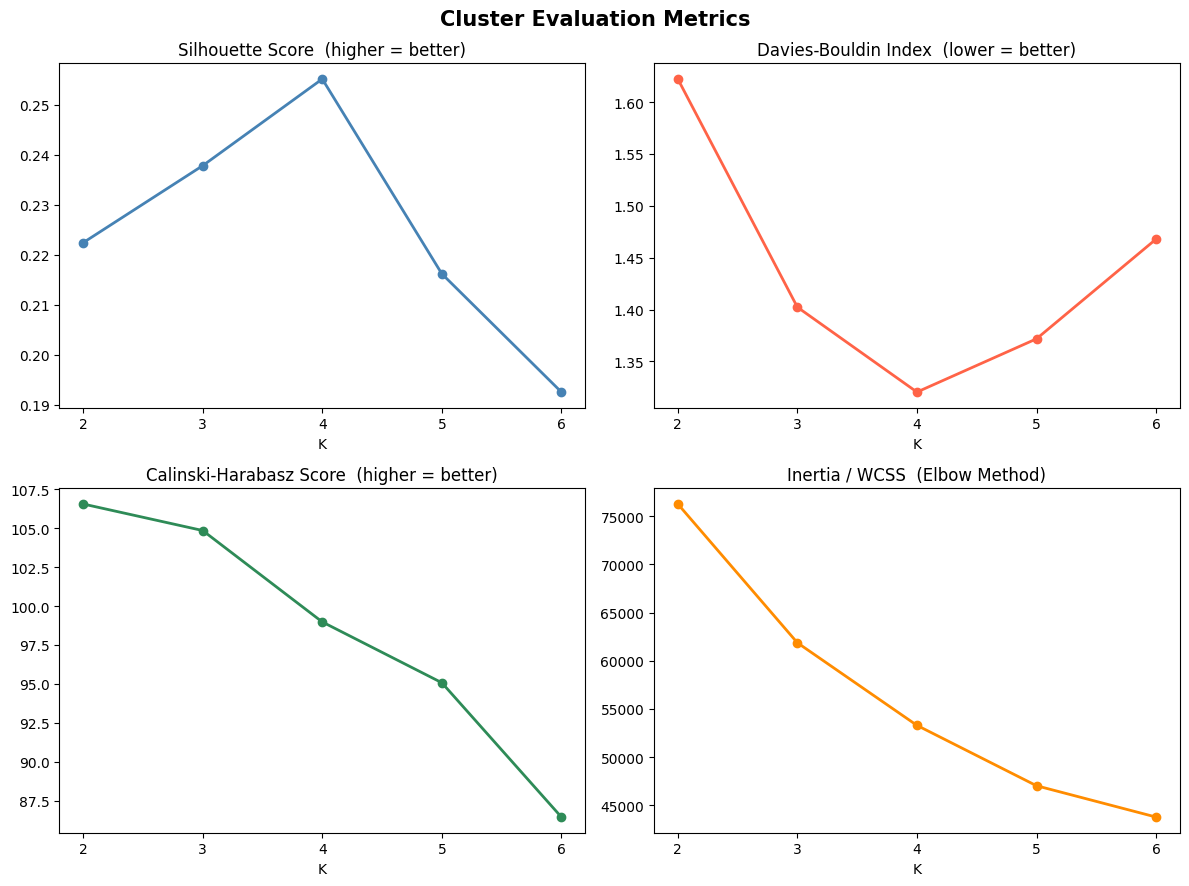

  Valid K candidates: [2, 3, 4, 5, 6]
  Winner (lowest combined rank): K=4

  Optimal K = 4  (Silhouette = 0.255)

[5] Assigning meditation levels ...
  Alpha/all features : 64 electrodes
  Theta/all features : 64 electrodes
  Beta/all  features : 64 electrodes

  Depth scores per cluster (higher = deeper meditation):
    Cluster 0 -> Level 0 — Baseline (mind-wandering)  (score=0.1794)
    Cluster 1 -> Level 1 — Light Relaxation  (score=0.2455)
    Cluster 2 -> Level 2 — Focused Attention  (score=0.5224)
    Cluster 3 -> Level 3 — Deep Meditation  (score=0.6069)

  Level distribution:
level_name
Level 0 — Baseline (mind-wandering)     79
Level 1 — Light Relaxation             121
Level 2 — Focused Attention            114
Level 3 — Deep Meditation               27

[6] Visualising ...


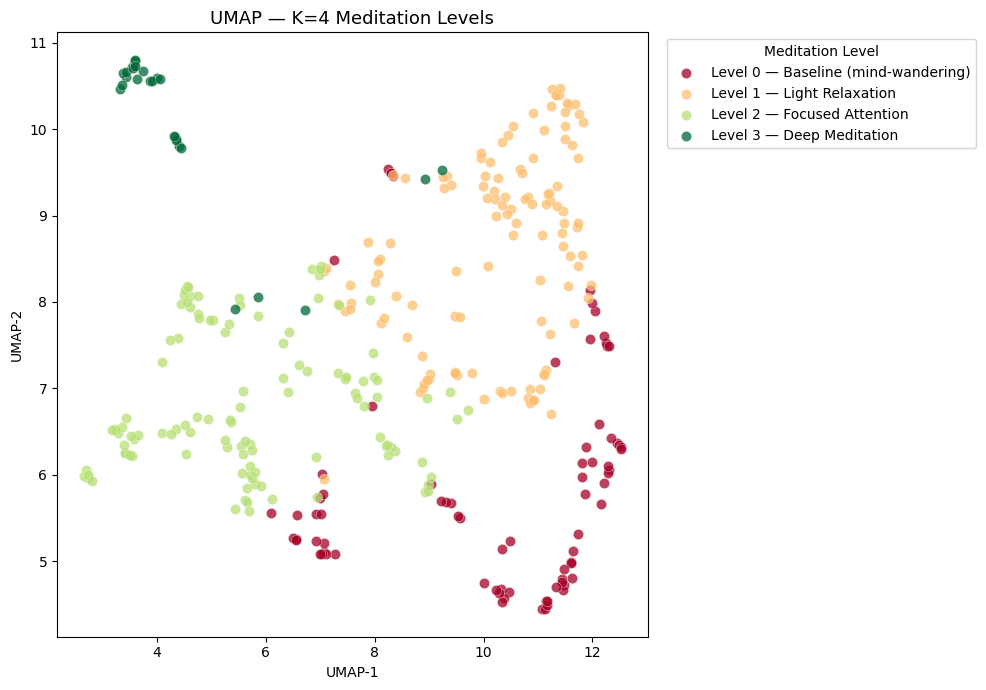

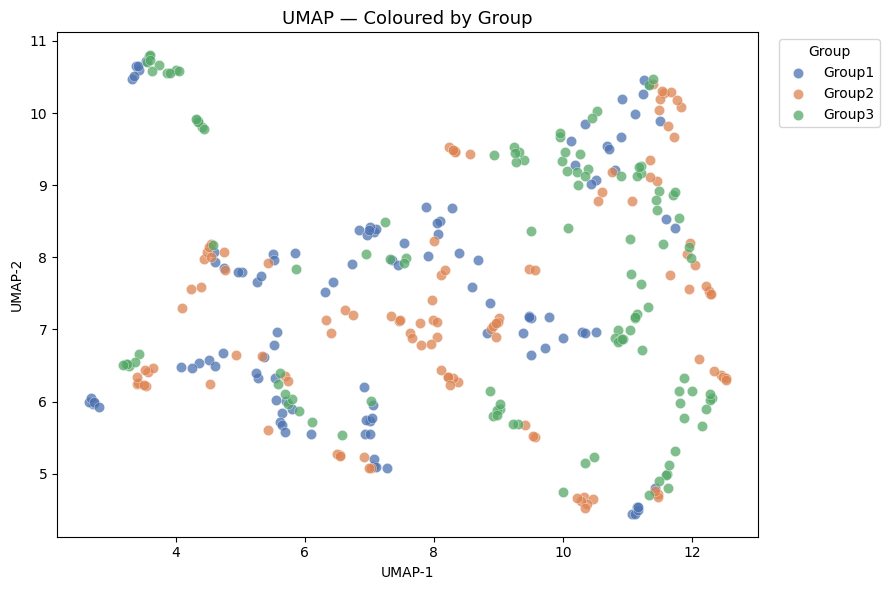

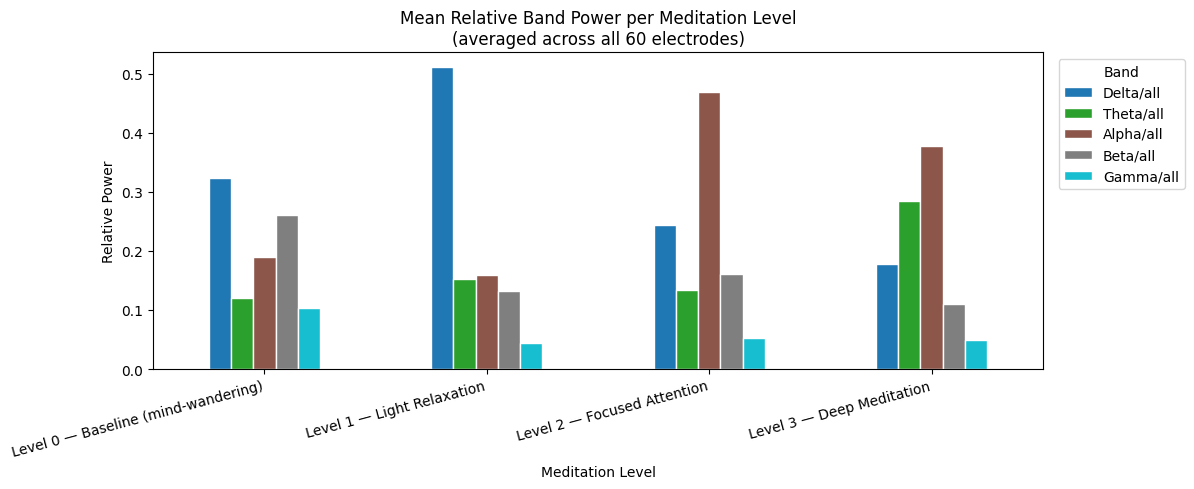

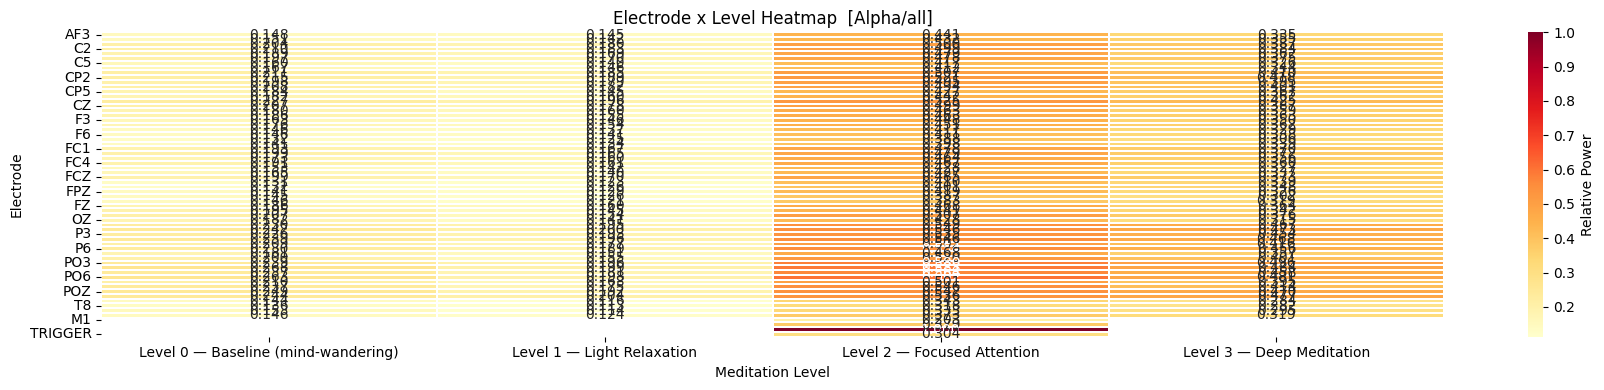

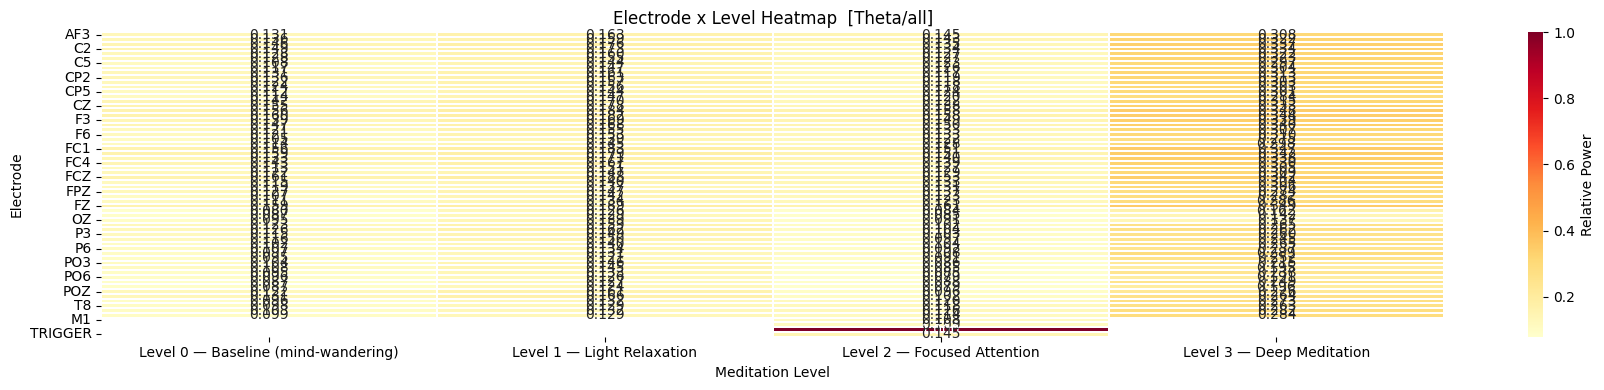

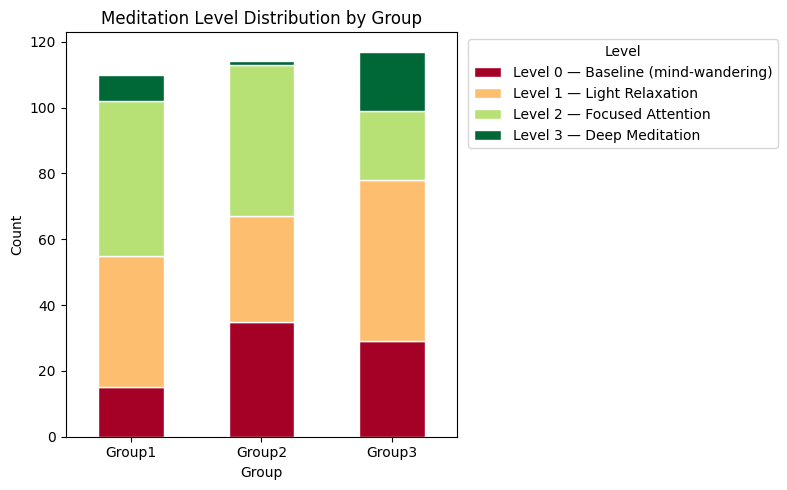

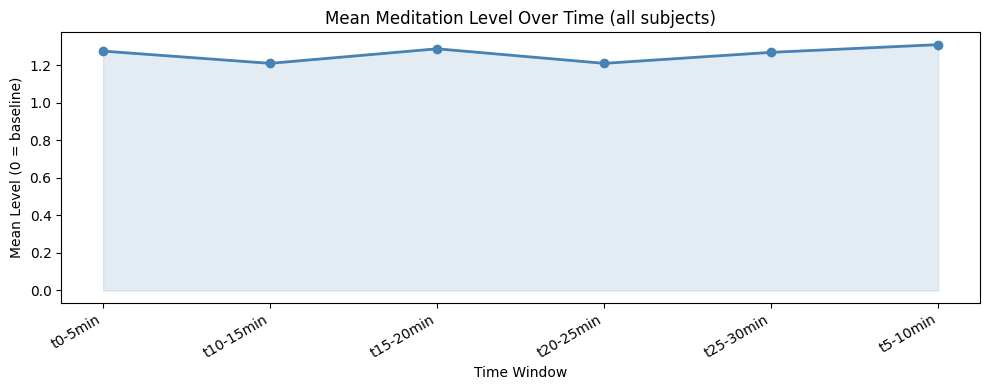


Saved:
  meditation_levels_output.csv  — full labeled dataset
  cluster_metrics.csv           — evaluation scores per K
  cluster_profiles.csv          — mean feature per level
  *.png                         — all visualisation plots

Done


In [ ]:
if __name__ == "__main__":
    labeled_df, metrics, optimal_k, cluster_profile = main()


### **Train Model with SVM**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC


In [ ]:
# Load data

file_path = '/content/meditation_levels_output.csv'
df = pd.read_csv(file_path)

print(f"Dataset Shape: {df.shape}")

Dataset Shape: (341, 647)


In [ ]:
# Preprocessing & Feature engineering

# Define the target variable
target_col = 'meditation_level'

# Define columns to drop (Metadata that shouldn't be used for training)
# We remove 'cluster' as it's just a proxy for the label
drop_cols = ['filepath', 'cluster', 'group', 'time_window', 'level_name', target_col]

# Filter to drop only columns that actually exist in the dataframe
cols_to_drop = [c for c in drop_cols if c in df.columns]

# Create Feature Matrix (X) and Target Vector (y)
X = df.drop(columns=cols_to_drop)
y = df[target_col]

# Check for non-numeric columns in X and drop them if any remain
X = X.select_dtypes(include=[np.number])

# Handle Missing Values (NaNs)
# SVMs cannot handle NaNs, so impute them with the mean of the column
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

print(f"Features used for training: {X_imputed.shape[1]}")


Features used for training: 650


In [ ]:
# Train-Test Split

groups = df['subject']  # Make sure, don't drop 'subject'

# 2. Splitting by Person (subjectID), not by Row
splitter = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, test_idx = next(splitter.split(X_imputed, y, groups))

X_train, X_test = X_imputed[train_idx], X_imputed[test_idx]
y_train, y_test = y.values[train_idx], y.values[test_idx]

# feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
# Model Training

param_grid = {
    'C': [0.1, 1, 10, 100],            # Regularization parameter
    'gamma': ['scale', 0.1, 0.01],     # Kernel coefficient
    'kernel': ['rbf', 'linear']        # Try both non-linear and linear boundaries
}

# GridSearchCV will find the best combination of parameters
grid = GridSearchCV(SVC(class_weight='balanced'), param_grid, refit=True, verbose=1, cv=5, n_jobs=-1)
grid.fit(X_train_scaled, y_train)

print(f"\nBest Parameters Found: {grid.best_params_}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best Parameters Found: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}


In [ ]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test_scaled)



Model Accuracy: 89.22%

Classification Report:
                      precision    recall  f1-score   support

  Level 0 (Baseline)       1.00      0.95      0.98        22
Level 1 (Relaxation)       0.79      1.00      0.88        34
     Level 2 (Focus)       0.93      0.85      0.89        33
      Level 3 (Deep)       1.00      0.62      0.76        13

            accuracy                           0.89       102
           macro avg       0.93      0.85      0.88       102
        weighted avg       0.91      0.89      0.89       102



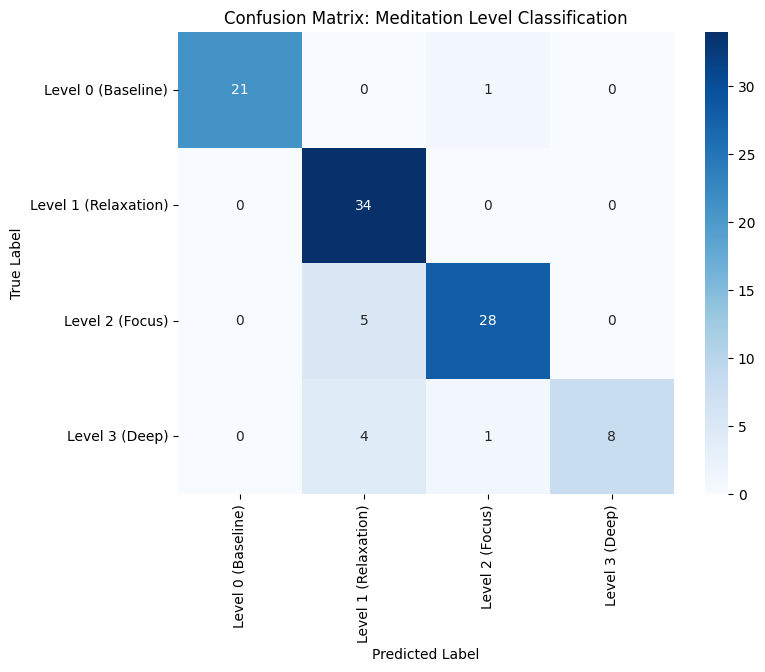

In [ ]:
# Evaluation

acc = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {acc:.2%}")

print("\nClassification Report:")
# Map the numeric labels back to names for readability if available
target_names = ['Level 0 (Baseline)', 'Level 1 (Relaxation)', 'Level 2 (Focus)', 'Level 3 (Deep)']
print(classification_report(y_test, y_pred, target_names=target_names))

# Confusion Matrix Visualization
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Meditation Level Classification')
plt.show()


### **SVM Improved Model**

In [ ]:
# All Dependencies
import subprocess, sys
def pip(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

try:
    from imblearn.over_sampling import SMOTE
    HAS_SMOTE = True
except ImportError:
    pip('imbalanced-learn')
    from imblearn.over_sampling import SMOTE
    HAS_SMOTE = True

try:
    from scipy import stats as sp_stats
except ImportError:
    pip('scipy')
    from scipy import stats as sp_stats

import os, pickle, warnings, json
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (GroupKFold, StratifiedKFold, GridSearchCV, cross_val_score)
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay)
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings('ignore')
print("✅ All imports successful")
print(f"   SMOTE available : {HAS_SMOTE}")


✅ All imports successful
   SMOTE available : True


In [ ]:
# configuration

DATA_PATH  = '/content/meditation_levels_output.csv'
OUTPUT_DIR = '/content/model_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

MODEL_PATH    = os.path.join(OUTPUT_DIR, 'meditation_svm_classifier.pkl')
SCALER_PATH   = os.path.join(OUTPUT_DIR, 'scaler.pkl')
FEATURES_PATH = os.path.join(OUTPUT_DIR, 'model_feature_names.pkl')
REPORT_PATH   = os.path.join(OUTPUT_DIR, 'training_report.txt')
CM_PATH       = os.path.join(OUTPUT_DIR, 'confusion_matrix.png')
FEAT_BAR_PATH = os.path.join(OUTPUT_DIR, 'feature_importance_proxy.png')
METRICS_PATH  = os.path.join(OUTPUT_DIR, 'cv_metrics.json')


BANDS = ['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma']

LEVEL_NAMES = {
    0: "Level 0 — Baseline (mind-wandering)",
    1: "Level 1 — Light Relaxation",
    2: "Level 2 — Focused Attention",
    3: "Level 3 — Deep Meditation",
}

# Muse headset → Mendeley 64-ch equivalents
# These channels are the closest spatial neighbours, allowing the model
# trained on dense-array data to generalise to consumer Muse headsets.
MUSE_CHANNEL_MAP = {
    'TP9':  ['TP7', 'T7', 'TP9', 'P7', 'P9'],
    'AF7':  ['AF3', 'F7', 'AF7', 'Fp1', 'FP1', 'F5', 'F3'],
    'AF8':  ['AF4', 'F8', 'AF8', 'Fp2', 'FP2', 'F6', 'F4'],
    'TP10': ['TP8', 'T8', 'TP10', 'P8', 'P10'],
}

# Frontal asymmetry (alpha suppression L>R correlates with positive affect)
FRONTAL_LEFT_CHANNELS  = ['AF3', 'F3', 'F7', 'AF7', 'FP1', 'Fp1', 'F5', 'FC1', 'FC3']
FRONTAL_RIGHT_CHANNELS = ['AF4', 'F4', 'F8', 'AF8', 'FP2', 'Fp2', 'F6', 'FC2', 'FC4']

# Mid-frontal theta: hallmark of deep meditation / cognitive control
FRONTAL_THETA_CHANNELS = ['AF3', 'AF4', 'AF7', 'AF8', 'F3', 'F4', 'FZ',
                           'FCZ', 'FP1', 'FP2', 'Fp1', 'Fp2', 'F7', 'F8']

# Posterior / occipital alpha: relaxed alertness signal
POSTERIOR_ALPHA_CHANNELS = ['O1', 'O2', 'OZ', 'PO3', 'PO4', 'PO7', 'PO8',
                              'P7', 'P8', 'TP7', 'TP8', 'TP9', 'TP10']

# SVM grid (broad → focused)
SVM_PARAM_GRID = {
    'C':     [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.001],
}

print("✅ Configuration loaded")
print(f"   Output directory : {OUTPUT_DIR}")
print(f"   Data path        : {DATA_PATH}")


✅ Configuration loaded
   Output directory : /content/model_outputs
   Data path        : /content/meditation_levels_output.csv


In [ ]:
# load & preprocess data

df = pd.read_csv(DATA_PATH)
print(f"Dataset shape   : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Unique subjects : {df['subject'].nunique() if 'subject' in df.columns else 'N/A'}")
print()

# Label distribution
print("Meditation level distribution:")
vc = df['meditation_level'].value_counts().sort_index()
for lvl, cnt in vc.items():
    bar = '█' * int(cnt / vc.max() * 30)
    name = LEVEL_NAMES.get(lvl, f'Level {lvl}')
    print(f"  {lvl}  {name:<42s}  {cnt:>3d}  {bar}")

# Subject info
if 'subject' in df.columns:
    groups_arr = df['subject'].values
    n_subjects = len(np.unique(groups_arr))
    sizes = df.groupby('subject').size()
    print(f"\nRows per subject : min={sizes.min()} | mean={sizes.mean():.1f} | max={sizes.max()}")
else:
    groups_arr = None
    n_subjects = 0
    print("\n No 'subject' column — subject-independent CV not possible")


Dataset shape   : 341 rows × 647 columns
Unique subjects : 60

Meditation level distribution:
  0  Level 0 — Baseline (mind-wandering)          79  ███████████████████
  1  Level 1 — Light Relaxation                  121  ██████████████████████████████
  2  Level 2 — Focused Attention                 114  ████████████████████████████
  3  Level 3 — Deep Meditation                    27  ██████

Rows per subject : min=3 | mean=5.7 | max=6


In [ ]:
# Channel Discovery & Muse-Proximity Strategy

META_COLS = {'Condition', 'TRIGGER', 'M1', 'M2', 'group', 'subject',
             'time_window', 'filepath', 'cluster', 'meditation_level', 'level_name'}

rel_band_cols      = {}   # All relative power cols
abs_band_cols      = {}   # All absolute power cols
muse_rel_band_cols = {}   # Muse-proximity relative power cols
muse_abs_band_cols = {}   # Muse-proximity absolute power cols

all_muse_ch = set()
for ch_list in MUSE_CHANNEL_MAP.values():
    all_muse_ch.update([c.upper() for c in ch_list])

print(f"{'Band':<8}  {'All rel':>8}  {'All abs':>8}  {'Muse rel':>9}  {'Muse abs':>9}")
print('-' * 55)
for band in BANDS:
    rel_band_cols[band] = [c for c in df.columns
                           if f'_{band}/all' in c
                           and not any(m in c for m in META_COLS)]
    abs_band_cols[band] = [c for c in df.columns
                           if c.endswith(f'_{band}') and '/all' not in c
                           and not any(m in c for m in META_COLS)]
    muse_rel_band_cols[band] = [
        c for c in rel_band_cols[band]
        if any(ch in c.upper() for ch in all_muse_ch)
    ]
    muse_abs_band_cols[band] = [
        c for c in abs_band_cols[band]
        if any(ch in c.upper() for ch in all_muse_ch)
    ]
    print(f"{band:<8}  {len(rel_band_cols[band]):>8}  {len(abs_band_cols[band]):>8}"
          f"  {len(muse_rel_band_cols[band]):>9}  {len(muse_abs_band_cols[band]):>9}")

muse_coverage = sum(1 for b in BANDS if muse_rel_band_cols[b] or muse_abs_band_cols[b])

if muse_coverage >= 4:
    use_rel = muse_rel_band_cols
    use_abs = muse_abs_band_cols
    channel_strategy = "Muse-proximity (reduces domain gap for cross-dataset use)"
    print(f"\n✅ Strategy: Muse-proximity channels ({muse_coverage}/5 bands covered)")
else:
    use_rel = rel_band_cols
    use_abs = abs_band_cols
    channel_strategy = "All channels (Muse-proximity coverage insufficient)"
    print(f"\n⚠️  Strategy: All channels (Muse coverage only {muse_coverage}/5 bands)")

print(f"   Rationale: By restricting to Muse-equivalent electrode sites, the")
print(f"   19 engineered features remain computable on any EEG headset that")
print(f"   covers frontal, temporal, and parieto-occipital regions.")

# Clean power cols
all_power_cols = [c for b in BANDS for c in use_rel[b] + use_abs[b]]
df[all_power_cols] = df[all_power_cols].apply(pd.to_numeric, errors='coerce')
for c in all_power_cols:
    if df[c].isna().any():
        df[c].fillna(df[c].median(), inplace=True)


Band       All rel   All abs   Muse rel   Muse abs
-------------------------------------------------------
Delta           60        60         18         18
Theta           60        60         18         18
Alpha           60        60         18         18
Beta            60        60         18         18
Gamma           60        60         18         18

✅ Strategy: Muse-proximity channels (5/5 bands covered)
   Rationale: By restricting to Muse-equivalent electrode sites, the
   19 engineered features remain computable on any EEG headset that
   covers frontal, temporal, and parieto-occipital regions.


#### Feature Engineering (19 features)

These features are **headset-agnostic** — they can be recomputed from any EEG device
that covers frontal, temporal, and occipital regions, making the model robust
across datasets (Muse, OpenBCI, EMOTIV, research-grade 64-ch, etc.).

| Group | Features | Neuroscience Rationale |
|---|---|---|
| Mean relative band power | × 5 | Global power profile per session |
| Spatial std per band | × 5 | Topographic homogeneity — deep meditation = more uniform |
| Band ratios | × 6 | Normalised indices robust to amplitude differences across headsets |
| Frontal alpha asymmetry | × 1 | Left > Right alpha → positive affect / relaxation |
| Frontal theta mean | × 1 | Mid-frontal theta marker of focused/deep states |
| Posterior alpha mean | × 1 | Occipital alpha → sensory gating & relaxed alertness |

In [ ]:
eps  = 1e-8
feat = pd.DataFrame(index=df.index)

# ── 5a. Mean relative band power (5 features) ─────────────────────────────────
for band in BANDS:
    if use_rel[band]:
        feat[f'mean_rel_{band}'] = df[use_rel[band]].mean(axis=1)
    elif use_abs[band]:
        total = sum(df[use_abs[b]].mean(axis=1) for b in BANDS) + eps
        feat[f'mean_rel_{band}'] = df[use_abs[band]].mean(axis=1) / total
    else:
        feat[f'mean_rel_{band}'] = 0.0
        print(f"  ⚠️  No columns for {band} — set to 0")

# ── 5b. Spatial std per band (5 features) ─────────────────────────────────────
for band in BANDS:
    if use_rel[band]:
        feat[f'std_rel_{band}'] = df[use_rel[band]].std(axis=1).fillna(0)
    elif use_abs[band]:
        total = sum(df[use_abs[b]].mean(axis=1) for b in BANDS) + eps
        feat[f'std_rel_{band}'] = (
            df[use_abs[band]].div(total, axis=0).std(axis=1).fillna(0)
        )
    else:
        feat[f'std_rel_{band}'] = 0.0

# ── 5c. Band-power ratios (6 features) ────────────────────────────────────────
feat['ratio_theta_alpha'] = feat['mean_rel_Theta'] / (feat['mean_rel_Alpha'] + eps)
feat['ratio_alpha_beta']  = feat['mean_rel_Alpha'] / (feat['mean_rel_Beta']  + eps)
feat['ratio_delta_alpha'] = feat['mean_rel_Delta'] / (feat['mean_rel_Alpha'] + eps)
feat['ratio_theta_beta']  = feat['mean_rel_Theta'] / (feat['mean_rel_Beta']  + eps)
feat['ratio_delta_beta']  = feat['mean_rel_Delta'] / (feat['mean_rel_Beta']  + eps)
feat['ratio_gamma_alpha'] = feat['mean_rel_Gamma'] / (feat['mean_rel_Alpha'] + eps)

# ── 5d. Frontal alpha asymmetry (1 feature) ───────────────────────────────────
left_fa  = [c for c in use_rel['Alpha']
            if any(ch.upper() in c.upper() for ch in FRONTAL_LEFT_CHANNELS)]
right_fa = [c for c in use_rel['Alpha']
            if any(ch.upper() in c.upper() for ch in FRONTAL_RIGHT_CHANNELS)]
feat['frontal_alpha_asymm'] = (
    df[left_fa].mean(axis=1) - df[right_fa].mean(axis=1)
    if left_fa and right_fa else pd.Series(0.0, index=df.index)
)

# ── 5e. Frontal theta mean (1 feature) ────────────────────────────────────────
frontal_theta = [c for c in use_rel['Theta']
                 if any(ch.upper() in c.upper() for ch in FRONTAL_THETA_CHANNELS)]
feat['frontal_theta_mean'] = (
    df[frontal_theta].mean(axis=1) if frontal_theta else feat['mean_rel_Theta']
)

# ── 5f. Posterior alpha mean (1 feature) ──────────────────────────────────────
occ_alpha = [c for c in use_rel['Alpha']
             if any(ch.upper() in c.upper() for ch in POSTERIOR_ALPHA_CHANNELS)]
feat['occipital_alpha_mean'] = (
    df[occ_alpha].mean(axis=1) if occ_alpha else feat['mean_rel_Alpha']
)

feature_cols = list(feat.columns)
print(f"✅ {len(feature_cols)} features engineered:")
for i, f in enumerate(feature_cols):
    print(f"   [{i:02d}] {f}")

X = feat.values.astype(np.float64)
y = df['meditation_level'].values.astype(int)

# Remove any non-finite rows
bad = ~np.isfinite(X).all(axis=1)
if bad.any():
    print(f"\n⚠️  Removing {bad.sum()} rows with non-finite values")
    X = X[~bad]; y = y[~bad]
    df = df[~bad].reset_index(drop=True)
    groups_arr = groups_arr[~bad] if groups_arr is not None else None

valid = np.isin(y, [0, 1, 2, 3])
if not valid.all():
    print(f"⚠️  Removing {(~valid).sum()} rows with invalid labels")
    X = X[valid]; y = y[valid]
    df = df[valid].reset_index(drop=True)
    groups_arr = groups_arr[valid] if groups_arr is not None else None

print(f"\n Final dataset : {len(y)} samples × {X.shape[1]} features")
print(f" Class counts  : { {int(k): int(v) for k, v in zip(*np.unique(y, return_counts=True))} }")


✅ 19 features engineered:
   [00] mean_rel_Delta
   [01] mean_rel_Theta
   [02] mean_rel_Alpha
   [03] mean_rel_Beta
   [04] mean_rel_Gamma
   [05] std_rel_Delta
   [06] std_rel_Theta
   [07] std_rel_Alpha
   [08] std_rel_Beta
   [09] std_rel_Gamma
   [10] ratio_theta_alpha
   [11] ratio_alpha_beta
   [12] ratio_delta_alpha
   [13] ratio_theta_beta
   [14] ratio_delta_beta
   [15] ratio_gamma_alpha
   [16] frontal_alpha_asymm
   [17] frontal_theta_mean
   [18] occipital_alpha_mean

 Final dataset : 341 samples × 19 features
 Class counts  : {0: 79, 1: 121, 2: 114, 3: 27}


#### Label Circularity Diagnostic

> **Why this matters for cross-dataset robustness:**
> The Mendeley labels were produced by k-means clustering on the same EEG band-power
> features. A depth-1 decision tree accuracy > 70 % means the mapping is largely circular —
> the model learns to reproduce the clustering algorithm, not actual brain states.
> This cell quantifies the problem so you can make an informed decision.


In [ ]:
print("Label circularity check (decision tree trained on same features):")
print(f"{'Depth':>6}  {'Train Acc':>10}")
print('-' * 22)
for d in [1, 2, 3]:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X, y)
    acc_d = accuracy_score(y, dt.predict(X))
    flag  = ' ⚠️  CIRCULAR' if d == 1 and acc_d > 0.70 else ''
    print(f"{d:>6}  {acc_d:>10.3f}{flag}")

dt1 = DecisionTreeClassifier(max_depth=1, random_state=42)
dt1.fit(X, y)
dt1_acc = accuracy_score(y, dt1.predict(X))
label_circularity_warning = dt1_acc > 0.70

print()
if label_circularity_warning:
    print(f"⚠️  Depth-1 tree achieves {dt1_acc:.1%}.")
    print("   Labels are likely derived from these band-power features.")
    print("   Cross-dataset generalisation will be limited by label quality.")
    print("   Recommendation: obtain externally validated meditation labels.")
else:
    print(f"✅ No strong circularity detected (depth-1 acc = {dt1_acc:.1%})")


Label circularity check (decision tree trained on same features):
 Depth   Train Acc
----------------------
     1       0.657
     2       0.903
     3       0.935

✅ No strong circularity detected (depth-1 acc = 65.7%)


In [ ]:
# hyperparameter tuning

print("Tuning SVM (RBF kernel) via GridSearchCV …")
_sc_pre = StandardScaler()
X_pre   = _sc_pre.fit_transform(X)

gs = GridSearchCV(
    SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
    SVM_PARAM_GRID,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='balanced_accuracy',   # more robust than accuracy for imbalanced classes
    n_jobs=-1,
    verbose=0,
)
gs.fit(X_pre, y)
best_C     = gs.best_params_['C']
best_gamma = gs.best_params_['gamma']

print(f"✅ Best params        : C={best_C}, gamma={best_gamma}")
print(f"   Best balanced acc : {gs.best_score_:.3f}")

SVM_PARAMS = dict(
    kernel='rbf',
    C=best_C,
    gamma=best_gamma,
    class_weight='balanced',
    probability=True,
    random_state=42,
)


Tuning SVM (RBF kernel) via GridSearchCV …
✅ Best params        : C=100, gamma=0.001
   Best balanced acc : 0.924


#### Subject-Independent Cross-Validation

Uses **GroupKFold** so that all time-windows from one subject stay in the same
fold — this prevents the optimistic leakage that occurs when a standard
StratifiedKFold splits time-windows from the same person into train and test.

SMOTE is applied **inside each fold** (on training data only) to avoid
synthetic samples from the minority class leaking into test evaluation.


In [ ]:
if groups_arr is not None and n_subjects >= 5:
    n_splits = min(5, n_subjects)
    cv       = GroupKFold(n_splits=n_splits)
    cv_label = f"Subject-Independent GroupKFold (n_splits={n_splits})"

    fold_accs, fold_bal_accs = [], []
    all_y_true, all_y_pred   = [], []

    print(f"Running {n_splits}-fold subject-independent CV …\n")
    print(f"{'Fold':>5}  {'Subjects in test':>40}  {'n':>5}  {'Acc':>6}  {'BalAcc':>8}")
    print('-' * 75)

    for fold_i, (train_idx, test_idx) in enumerate(cv.split(X, y, groups_arr)):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        # SMOTE inside fold (training only)
        if HAS_SMOTE:
            counts    = np.bincount(y_tr)
            min_count = min(counts[counts > 0])
            if min_count >= 6:
                smote = SMOTE(random_state=42, k_neighbors=min(5, min_count - 1))
                X_tr, y_tr = smote.fit_resample(X_tr, y_tr)

        # Scale inside fold
        sc = StandardScaler()
        X_tr_s = sc.fit_transform(X_tr)
        X_te_s = sc.transform(X_te)

        fold_clf = SVC(**SVM_PARAMS)
        fold_clf.fit(X_tr_s, y_tr)
        y_pred_fold = fold_clf.predict(X_te_s)

        from sklearn.metrics import balanced_accuracy_score
        acc_f  = accuracy_score(y_te, y_pred_fold)
        bacc_f = balanced_accuracy_score(y_te, y_pred_fold)
        fold_accs.append(acc_f)
        fold_bal_accs.append(bacc_f)
        all_y_true.extend(y_te)
        all_y_pred.extend(y_pred_fold)

        subj_test = list(np.unique(groups_arr[test_idx]))
        print(f"{fold_i+1:>5}  {str(subj_test)[:40]:>40}  {len(y_te):>5}  "
              f"{acc_f:>6.3f}  {bacc_f:>8.3f}")

    cv_scores     = np.array(fold_accs)
    cv_bal_scores = np.array(fold_bal_accs)
    all_y_true    = np.array(all_y_true)
    all_y_pred    = np.array(all_y_pred)

    overall_cv_acc  = accuracy_score(all_y_true, all_y_pred)
    overall_cv_bacc = balanced_accuracy_score(all_y_true, all_y_pred)

    # 95 % confidence interval
    if len(cv_scores) >= 3:
        ci_low, ci_high = sp_stats.t.interval(
            0.95, df=len(cv_scores)-1,
            loc=np.mean(cv_scores), scale=sp_stats.sem(cv_scores))
        ci_bal_low, ci_bal_high = sp_stats.t.interval(
            0.95, df=len(cv_bal_scores)-1,
            loc=np.mean(cv_bal_scores), scale=sp_stats.sem(cv_bal_scores))
    else:
        ci_low, ci_high = cv_scores.min(), cv_scores.max()
        ci_bal_low, ci_bal_high = cv_bal_scores.min(), cv_bal_scores.max()

    print(f"\n{'─'*55}")
    print(f"  Accuracy  : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}  "
          f"95% CI [{ci_low:.3f}, {ci_high:.3f}]")
    print(f"  Bal. Acc  : {cv_bal_scores.mean():.3f} ± {cv_bal_scores.std():.3f}  "
          f"95% CI [{ci_bal_low:.3f}, {ci_bal_high:.3f}]")
    print(f"  Overall   : acc={overall_cv_acc:.3f}  bal_acc={overall_cv_bacc:.3f}")
    print(f"  SMOTE     : {'applied per fold' if HAS_SMOTE else 'not available'}")
    print()

    present_labels = sorted(np.unique(y))
    cv_report = classification_report(
        all_y_true, all_y_pred,
        labels=present_labels,
        target_names=[LEVEL_NAMES[i] for i in present_labels]
    )
    print(cv_report)

    # Warn on low-support classes
    for lvl in present_labels:
        n_test = (all_y_true == lvl).sum()
        if n_test < 20:
            print(f"  ⚠️  Class {lvl} ({LEVEL_NAMES[lvl]}): only {n_test} test samples")

else:
    print("⚠️  No subject column — falling back to StratifiedKFold (optimistic)")
    cv_label = "StratifiedKFold (not subject-independent)"
    from sklearn.metrics import balanced_accuracy_score
    cv_scores     = cross_val_score(SVC(**SVM_PARAMS), X_pre, y,
                                    cv=StratifiedKFold(5, shuffle=True, random_state=42),
                                    scoring='accuracy')
    cv_bal_scores = cross_val_score(SVC(**SVM_PARAMS), X_pre, y,
                                    cv=StratifiedKFold(5, shuffle=True, random_state=42),
                                    scoring='balanced_accuracy')
    overall_cv_acc  = cv_scores.mean()
    overall_cv_bacc = cv_bal_scores.mean()
    ci_low, ci_high = cv_scores.min(), cv_scores.max()
    ci_bal_low, ci_bal_high = cv_bal_scores.min(), cv_bal_scores.max()
    cv_report  = "N/A (no subject column)"
    all_y_true = y; all_y_pred = y
    present_labels = sorted(np.unique(y))
    print(f"  Acc : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
    print(f"  Bal : {cv_bal_scores.mean():.3f} ± {cv_bal_scores.std():.3f}")


Running 5-fold subject-independent CV …

 Fold                          Subjects in test      n     Acc    BalAcc
---------------------------------------------------------------------------
    1  ['E1-17', 'E1-20', 'E1-4', 'E1-6', 'E1-7     69   0.899     0.672
    2  ['E1-1', 'E1-10', 'E1-8', 'E2-10', 'E2-1     69   0.913     0.902
    3  ['E1-13', 'E1-14', 'E1-19', 'E2-11', 'E2     68   0.956     0.892
    4  ['E1-12', 'E1-16', 'E1-18', 'E1-5', 'E2-     68   0.941     0.944
    5  ['E1-11', 'E1-15', 'E1-2', 'E1-3', 'E1-9     67   0.955     0.959

───────────────────────────────────────────────────────
  Accuracy  : 0.933 ± 0.023  95% CI [0.901, 0.965]
  Bal. Acc  : 0.874 ± 0.104  95% CI [0.729, 1.018]
  Overall   : acc=0.933  bal_acc=0.917
  SMOTE     : applied per fold

                                     precision    recall  f1-score   support

Level 0 — Baseline (mind-wandering)       0.91      0.92      0.92        79
         Level 1 — Light Relaxation       0.94      0.93    

In [ ]:
print("Fitting final SVM on full dataset …")

scaler_final = StandardScaler()
X_scaled     = scaler_final.fit_transform(X)

X_final, y_final = X_scaled, y
if HAS_SMOTE:
    counts    = np.bincount(y)
    min_count = min(counts[counts > 0])
    if min_count >= 6:
        smote_f  = SMOTE(random_state=42, k_neighbors=min(5, min_count - 1))
        X_final, y_final = smote_f.fit_resample(X_scaled, y)
        print(f"  SMOTE: {len(y)} → {len(y_final)} samples")

model_final = SVC(**SVM_PARAMS)
model_final.fit(X_final, y_final)

train_acc  = accuracy_score(y, model_final.predict(X_scaled))
gap        = train_acc - cv_scores.mean()
gap_flag   = '⚠️  overfitting' if gap > 0.10 else ('⚠️  mild' if gap > 0.05 else '✅ OK')

print(f"\n  Train accuracy : {train_acc:.3f}")
print(f"  CV accuracy    : {cv_scores.mean():.3f}")
print(f"  Train-CV gap   : {gap:.3f}  {gap_flag}")


Fitting final SVM on full dataset …
  SMOTE: 341 → 484 samples

  Train accuracy : 0.965
  CV accuracy    : 0.933
  Train-CV gap   : 0.032  ✅ OK


In [ ]:
# ── 10a. Pickle artefacts ─────────────────────────────────────────────────────
with open(MODEL_PATH,    'wb') as f: pickle.dump(model_final,  f)
with open(SCALER_PATH,   'wb') as f: pickle.dump(scaler_final, f)
with open(FEATURES_PATH, 'wb') as f: pickle.dump(feature_cols, f)
print(f"✅ Model   → {MODEL_PATH}")
print(f"✅ Scaler  → {SCALER_PATH}")
print(f"✅ Feats   → {FEATURES_PATH}")

# ── 10b. JSON metrics ─────────────────────────────────────────────────────────
metrics_dict = {
    "cv_strategy"          : cv_label,
    "n_samples"            : int(len(y)),
    "n_subjects"           : int(n_subjects),
    "n_features"           : int(len(feature_cols)),
    "channel_strategy"     : channel_strategy,
    "svm_params"           : {k: str(v) for k, v in SVM_PARAMS.items()},
    "cv_accuracy_mean"     : round(float(cv_scores.mean()), 4),
    "cv_accuracy_std"      : round(float(cv_scores.std()),  4),
    "cv_accuracy_ci_low"   : round(float(ci_low),           4),
    "cv_accuracy_ci_high"  : round(float(ci_high),          4),
    "cv_bal_acc_mean"      : round(float(cv_bal_scores.mean()), 4),
    "cv_bal_acc_std"       : round(float(cv_bal_scores.std()),  4),
    "cv_bal_acc_ci_low"    : round(float(ci_bal_low),           4),
    "cv_bal_acc_ci_high"   : round(float(ci_bal_high),          4),
    "train_accuracy"       : round(float(train_acc),           4),
    "train_cv_gap"         : round(float(gap),                 4),
    "label_circularity_dt1": round(float(dt1_acc),             4),
    "circularity_warning"  : bool(label_circularity_warning),
    "feature_names"        : feature_cols,
    "class_distribution"   : {str(int(k)): int(v)
                               for k, v in zip(*np.unique(y, return_counts=True))},
}
with open(METRICS_PATH, 'w') as f:
    json.dump(metrics_dict, f, indent=2)
print(f"✅ Metrics → {METRICS_PATH}")

# ── 10c. Text report ──────────────────────────────────────────────────────────
report_txt = f"""MEDITATION CLASSIFIER — TRAINING REPORT (SVM v3 — Robust)
=================================================================
Dataset        : {DATA_PATH}
Samples        : {len(y)}
Subjects       : {n_subjects}
Features       : {len(feature_cols)}
Channel strat  : {channel_strategy}

FEATURE NAMES
─────────────
{chr(10).join(f'  [{i:02d}] {f}' for i, f in enumerate(feature_cols))}

MODEL PARAMS (SVM RBF)
──────────────────────
  kernel          = rbf
  C               = {best_C}
  gamma           = {best_gamma}
  class_weight    = balanced
  probability     = True
  SMOTE           = {'yes' if HAS_SMOTE else 'no'}

LABEL CIRCULARITY DIAGNOSTIC
─────────────────────────────
  Depth-1 tree acc : {dt1_acc:.3f}  {'⚠️  CIRCULAR — labels likely derived from features' if label_circularity_warning else '✅ OK'}

CROSS-VALIDATION ({cv_label})
{'─' * 50}
  Fold scores (acc)    : {np.round(cv_scores, 3).tolist()}
  Accuracy             : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}  95% CI [{ci_low:.3f}, {ci_high:.3f}]
  Balanced Accuracy    : {cv_bal_scores.mean():.3f} ± {cv_bal_scores.std():.3f}  95% CI [{ci_bal_low:.3f}, {ci_bal_high:.3f}]
  Overall acc (pooled) : {overall_cv_acc:.3f}
  Overall bal acc      : {overall_cv_bacc:.3f}

FINAL MODEL
───────────
  Train accuracy       : {train_acc:.3f}
  Train-CV gap         : {gap:.3f}  {'⚠️  overfitting' if gap > 0.10 else '✅ OK' if gap <= 0.05 else '⚠️  mild'}

CLASS DISTRIBUTION
──────────────────
{chr(10).join(f'  Level {k}: {v} samples' for k, v in zip(*np.unique(y, return_counts=True)))}

CLASSIFICATION REPORT (CV pooled predictions)
──────────────────────────────────────────────
{cv_report}
"""
with open(REPORT_PATH, 'w') as f:
    f.write(report_txt)
print(f"✅ Report  → {REPORT_PATH}")


✅ Model   → /content/model_outputs/meditation_svm_classifier.pkl
✅ Scaler  → /content/model_outputs/scaler.pkl
✅ Feats   → /content/model_outputs/model_feature_names.pkl
✅ Metrics → /content/model_outputs/cv_metrics.json
✅ Report  → /content/model_outputs/training_report.txt


In [ ]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
cm_data = confusion_matrix(all_y_true, all_y_pred, labels=present_labels)
disp_labels = [
    "L{}\n{}".format(i, LEVEL_NAMES[i].split("—")[1].strip()[:12])
    for i in present_labels
]
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_data,
    display_labels=disp_labels
)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title(
    "Confusion Matrix — {}\nAcc={:.3f}  BalAcc={:.3f}".format(
        cv_label, overall_cv_acc, overall_cv_bacc),
    fontsize=9
)
plt.tight_layout()
plt.savefig(CM_PATH, dpi=150)
plt.show()
print("✅ Confusion matrix → " + CM_PATH)

# ── Feature Coefficient Proxy (|mean SVM weight| via linear SVM) ───────────────
print("\nFitting a linear SVM for feature importance proxy …")
from sklearn.svm import LinearSVC
lin_svc = LinearSVC(class_weight='balanced', max_iter=5000, random_state=42)
lin_svc.fit(X_scaled, y)
importance = np.abs(lin_svc.coef_).mean(axis=0)   # mean |coef| across classes

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e63946' if importance[i] == importance.max() else '#457b9d'
          for i in range(len(feature_cols))]
ax.barh(feature_cols, importance, color=colors)
ax.set_xlabel('Mean |coefficient| (Linear SVM proxy)')
ax.set_title('Feature Importance Proxy (Linear SVM coefficients)\n'
             '— Red bar = most discriminative feature')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FEAT_BAR_PATH, dpi=150)
plt.show()
print("✅ Feature importance → " + FEAT_BAR_PATH)

# ── Band Power by Meditation Level ────────────────────────────────────────────
band_means = {}
for band in BANDS:
    band_means[band] = feat['mean_rel_' + band].values

feat_df = pd.DataFrame(band_means)
feat_df['level'] = y
feat_df['level_name'] = [LEVEL_NAMES[l] for l in y]

fig, axes = plt.subplots(1, 5, figsize=(16, 4), sharey=False)
palette = ['#264653', '#2a9d8f', '#e9c46a', '#f4a261', '#e76f51']
for ax, band, color in zip(axes, BANDS, palette):
    sns.boxplot(data=feat_df, x='level', y=band, ax=ax, color=color)
    ax.set_title(band, fontweight='bold')
    ax.set_xlabel('Meditation Level')
    ax.set_ylabel('Mean Relative Power' if band == 'Delta' else '')

fig.suptitle('Mean Relative Band Power by Meditation Level', fontsize=13, fontweight='bold')
plt.tight_layout()
band_path = os.path.join(OUTPUT_DIR, 'band_power_by_level.png')
plt.savefig(band_path, dpi=150)
plt.show()
print("✅ Band power chart → " + band_path)


✅ Confusion matrix → /content/model_outputs/confusion_matrix.png

Fitting a linear SVM for feature importance proxy …
✅ Feature importance → /content/model_outputs/feature_importance_proxy.png
✅ Band power chart → /content/model_outputs/band_power_by_level.png
